In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Load Data
df = pd.read_csv("/content/karachi_raw_aqi.csv")
df['time'] = pd.to_datetime(df['time'])

# 2. Check Baseline Statistics
print("--- BASELINE STATISTICS ---")
display(df.describe().T) # The .T transposes it so it's easier to read

--- BASELINE STATISTICS ---


,count,mean,min,25%,50%,75%,max,std
time,47352,2023-09-14 11:30:00,2021-01-01 00:00:00,2022-05-09 05:45:00,2023-09-14 11:30:00,2025-01-19 17:15:00,2026-05-27 23:00:00,NaN
pm10,33432.0,63.231907,0.5,39.2,53.7,76.1,642.6,38.692483
pm2_5,33432.0,30.738335,0.4,19.3,25.4,36.1,448.9,19.312472
carbon_monoxide,33432.0,504.170735,46.0,222.0,352.0,638.0,5014.0,433.959617
nitrogen_dioxide,33432.0,21.573448,0.0,7.9,14.5,28.3,215.1,20.273644
sulphur_dioxide,33432.0,16.368366,0.2,7.1,12.8,20.4,260.1,14.673045
ozone,33432.0,75.321458,-1.0,44.0,64.0,98.0,680.0,46.488404
aerosol_optical_depth,33432.0,0.396015,0.03,0.23,0.33,0.49,2.08,0.241134
dust,33432.0,53.367402,0.0,11.0,29.0,68.0,1019.0,70.684713
uv_index,33432.0,1.626964,0.0,0.0,0.0,2.65,11.8,2.576959


### Systematic EDA Step 1: Identifying and Removing "Empty Vessel" Features
Before applying any complex data imputation or machine learning models, we must assess **Data Completeness**.

By calculating the total number of valid (non-null) records per feature, we can identify variables where the Open-Meteo regional sensors are either offline or unsupported in Karachi (e.g., specific pollen types). Any feature with a valid record count of `0` contains no signal, only noise.

In the visualization below, we plot the completeness of our dataset. Features highlighted in red have zero valid entries and will be systematically dropped to reduce dimensionality and optimize model training.

/tmp/ipykernel_10882/1304863285.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette=colors)


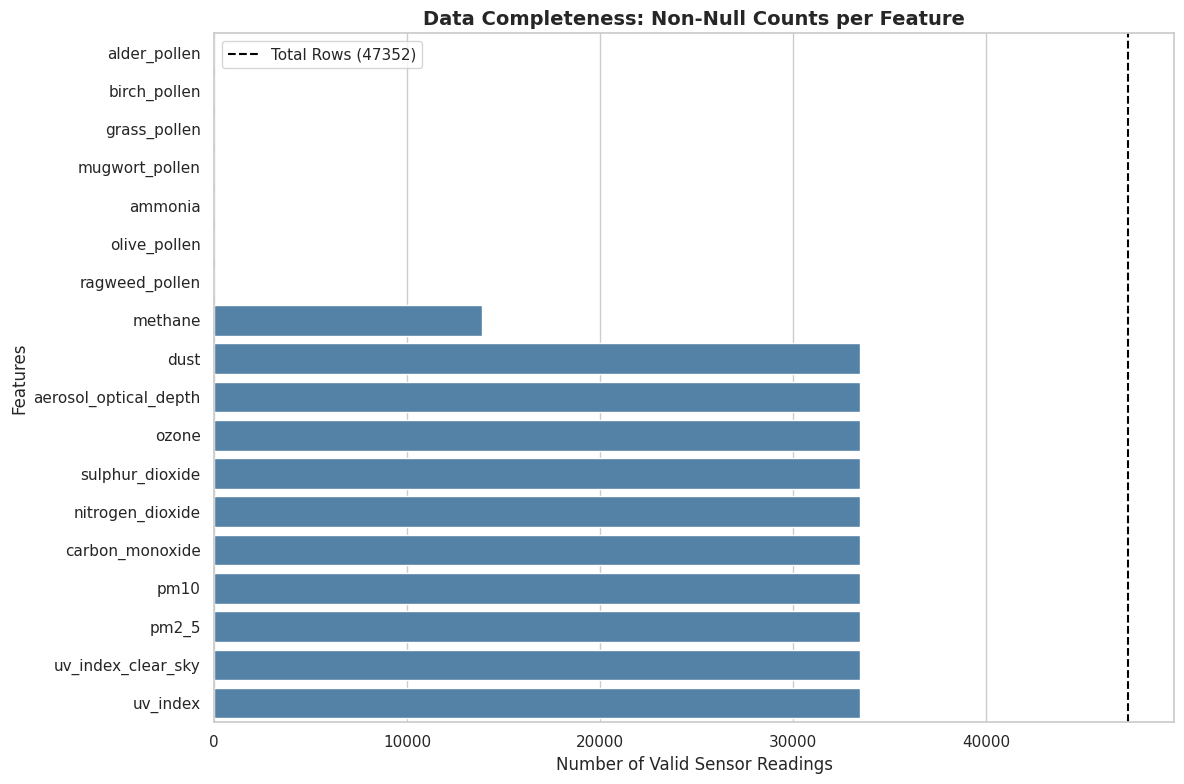

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate non-null counts for all columns except the timestamp
counts = df.drop(columns=['time']).count().sort_values()

plt.figure(figsize=(12, 8))

# Create a dynamic color palette: Red for 0 valid rows, Blue for valid data
colors = ['crimson' if c == 0 else 'steelblue' for c in counts]

# Plot the bar chart
sns.barplot(x=counts.values, y=counts.index, palette=colors)

# Add a dotted line showing the absolute maximum number of rows
plt.axvline(x=len(df), color='black', linestyle='--', label=f'Total Rows ({len(df)})')

plt.title("Data Completeness: Non-Null Counts per Feature", fontsize=14, fontweight='bold')
plt.xlabel("Number of Valid Sensor Readings")
plt.ylabel("Features")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Systematically find columns where the count of valid data is exactly 0
zero_count_cols = df.columns[df.count() == 0].tolist()

print(f"🚨 Identified {len(zero_count_cols)} features with 0 valid records:")
for col in zero_count_cols:
    print(f" - {col}")

# Drop these 'empty vessel' columns from the DataFrame
df = df.drop(columns=zero_count_cols)

print(f"\n✅ Features successfully dropped.")
print(f"Remaining columns in dataset: {len(df.columns)}")

🚨 Identified 7 features with 0 valid records:
 - ammonia
 - alder_pollen
 - birch_pollen
 - grass_pollen
 - mugwort_pollen
 - olive_pollen
 - ragweed_pollen

✅ Features successfully dropped.
Remaining columns in dataset: 12


### Systematic EDA Step 2: Two-Dimensional Missing Data Analysis
Before applying imputation techniques like Forward-Fill, we must understand the *anatomy* of our missing data. Missing values in time-series data usually occur in two ways:
1. **Column-wise Outages:** A specific sensor (e.g., Methane) breaks or is installed late, leaving massive gaps in just one feature.
2. **Row-wise Outages (Temporal Gaps):** The entire regional weather station goes offline, resulting in specific time periods where *all* features are simultaneously `NaN`.

By analyzing missing data across both axes, we can separate periods of total systemic failure (which must be dropped) from temporary sensor glitches (which can be safely imputed).

/tmp/ipykernel_10882/2697656118.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_cols.values, y=missing_cols.index, ax=axes[0], palette="magma")


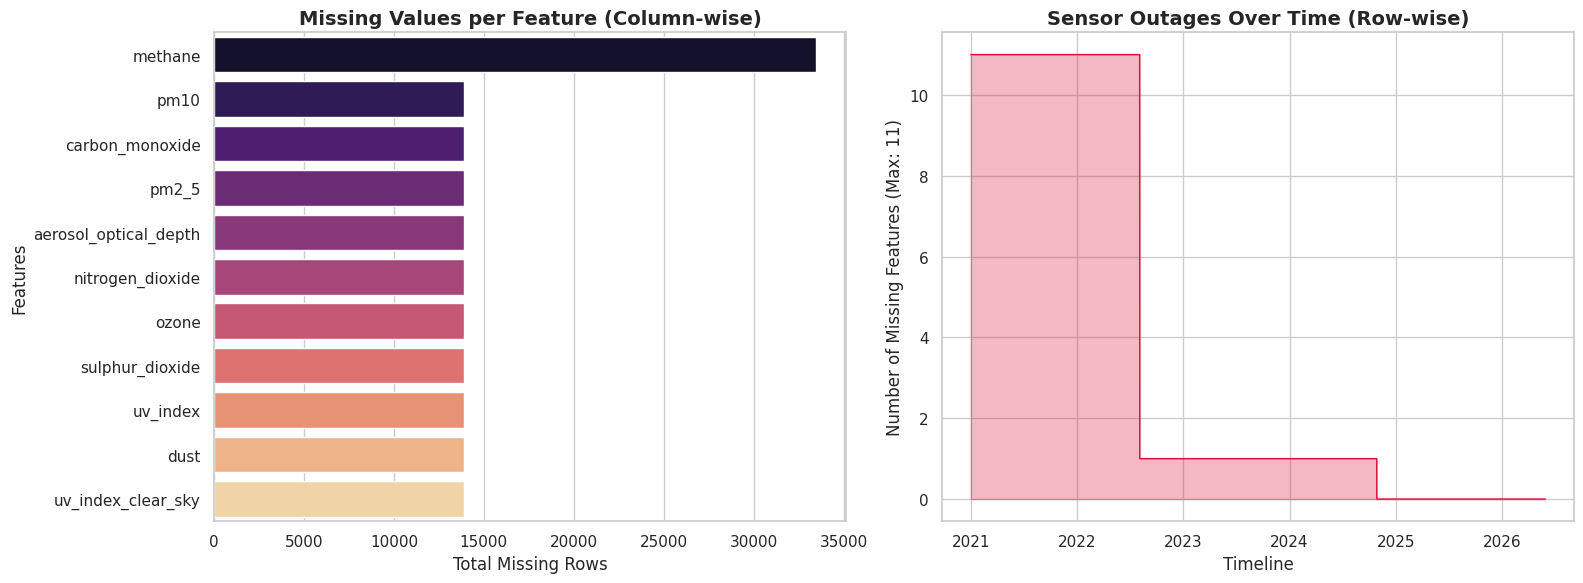

--- MISSING VALUES DIAGNOSTIC ---
Total timeline records (hours): 47352
Hours with perfect data (0 missing): 13896
Hours where ALL sensors were offline: 13920


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Column-wise missing values
missing_cols = df.isna().sum().sort_values(ascending=False)
missing_cols = missing_cols[missing_cols > 0] # Filter to only show columns with NaNs

# 2. Calculate Row-wise missing values over time
# We temporarily set 'time' as the index so our x-axis becomes a beautiful timeline
missing_rows_timeline = df.set_index('time').isna().sum(axis=1)
total_features = len(df.columns) - 1 # Subtract 1 because 'time' is never missing

# --- PLOTTING THE DASHBOARD ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Missing Values per Column
sns.barplot(x=missing_cols.values, y=missing_cols.index, ax=axes[0], palette="magma")
axes[0].set_title("Missing Values per Feature (Column-wise)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Total Missing Rows")
axes[0].set_ylabel("Features")

# Right Plot: Timeline of Outages (Row-wise)
axes[1].plot(missing_rows_timeline.index, missing_rows_timeline.values, color='crimson', linewidth=1)
axes[1].fill_between(missing_rows_timeline.index, missing_rows_timeline.values, color='crimson', alpha=0.3)
axes[1].set_title("Sensor Outages Over Time (Row-wise)", fontsize=14, fontweight='bold')
axes[1].set_ylabel(f"Number of Missing Features (Max: {total_features})")
axes[1].set_xlabel("Timeline")

plt.tight_layout()
plt.show()

# --- PRINT THE NUMERICAL SUMMARY ---
print("--- MISSING VALUES DIAGNOSTIC ---")
print(f"Total timeline records (hours): {len(df)}")
print(f"Hours with perfect data (0 missing): {sum(missing_rows_timeline == 0)}")
print(f"Hours where ALL sensors were offline: {sum(missing_rows_timeline == total_features)}")

### Systematic EDA Step 3: Removing Systemic Outages
Based on our two-dimensional analysis, we identified exactly 13,920 hours (primarily concentrated in 2021-2022) where the entire weather station was offline, resulting in 100% missing feature data.

Imputing these massive temporal gaps would artificially invent over a year of synthetic weather patterns, destroying the integrity of our dataset. Therefore, we systematically drop any row where *all* sensor features are simultaneously `NaN`.

In [6]:
# 1. Define the columns to check (everything except the 'time' column)
feature_cols = df.columns.drop('time')

# 2. Drop rows where ALL of these feature columns are missing
df = df.dropna(subset=feature_cols, how='all')

# 3. Print the results to verify
print("🚨 Systemic Outages Removed.")
print(f"✅ Remaining valid timeline records: {len(df)}")

# Let's take a quick peek at the remaining missing data
print("\n--- REMAINING MISSING VALUES PER FEATURE ---")
print(df.isna().sum())

🚨 Systemic Outages Removed.
✅ Remaining valid timeline records: 33432

--- REMAINING MISSING VALUES PER FEATURE ---
time                         0
pm10                         0
pm2_5                        0
carbon_monoxide              0
nitrogen_dioxide             0
sulphur_dioxide              0
ozone                        0
aerosol_optical_depth        0
dust                         0
uv_index                     0
uv_index_clear_sky           0
methane                  19536
dtype: int64


### Systematic EDA Step 4: High-Sparsity Feature Removal & Domain Context
Our missing value diagnostic revealed that `methane` is missing 19,536 out of 33,432 records (58.4% missing).

**Statistical Rationale:** Any feature with >50% missing data requires too much synthetic imputation, which introduces severe bias into the model.
**Domain Rationale:** Methane is a greenhouse gas that drives long-term climate change, but it is not a "Criteria Air Pollutant." It is not factored into standard daily AQI formulas, which rely on particulate matter (PM2.5/PM10) and reactive gases (NO2, Ozone) that directly impact human respiratory health.

Therefore, we systematically drop `methane` to reduce noise and prevent imputation bias.

In [7]:
# 1. Drop features with more than 50% missing data
threshold = len(df) * 0.50
high_sparsity_cols = df.columns[df.isna().sum() > threshold].tolist()

print(f"🚨 Dropping High-Sparsity Features (>50% missing): {high_sparsity_cols}")
df = df.drop(columns=high_sparsity_cols)

# 2. Final Imputation for the remaining minor gaps
# Now that systemic gaps and broken sensors are gone, it is finally safe
# to use Forward Fill to patch short, temporary sensor glitches (like a 2-hour outage)
df = df.ffill()

print("\n✅ Dataset is mathematically clean and complete.")
print("Final Missing Values:")
print(df.isna().sum())

🚨 Dropping High-Sparsity Features (>50% missing): ['methane']

✅ Dataset is mathematically clean and complete.
Final Missing Values:
time                     0
pm10                     0
pm2_5                    0
carbon_monoxide          0
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aerosol_optical_depth    0
dust                     0
uv_index                 0
uv_index_clear_sky       0
dtype: int64


### Systematic EDA Step 5: Feature Dictionary & Domain Context

Before progressing to feature selection and engineering, it is crucial to understand the physical reality of the data we are modeling.

**What is the Air Quality Index (AQI)?**
The AQI is a standardized scale used by governments to communicate how polluted the air currently is or how polluted it is forecast to become. It is mathematically derived from the concentration of specific "Criteria Air Pollutants." As AQI rises, public health risks increase severely.

**Our Remaining Features & Their Relevance to Karachi:**
* **Particulate Matter (`pm2_5` & `pm10`):** Tiny breathable particles. In Karachi, this is the primary driver of hazardous AQI, stemming from heavy vehicle exhaust, unregulated construction, and the burning of municipal waste.
* **Nitrogen Dioxide (`nitrogen_dioxide`):** A highly toxic reddish-brown gas. Primarily emitted by the massive volume of traffic congestion on major arteries like Shahrah-e-Faisal and heavy diesel trucks.
* **Carbon Monoxide (`carbon_monoxide`):** A colorless, odorless gas from incomplete combustion. Highly relevant due to widespread use of backup fuel generators during power outages and heavy traffic.
* **Sulphur Dioxide (`sulphur_dioxide`):** A toxic gas smelling of burnt matches. In Karachi, this is largely driven by industrial zones (SITE, Korangi) and shipping emissions from Port Qasim and KPT.
* **Ozone (`ozone`):** Ground-level "smog" (not the atmospheric ozone layer). It is not emitted directly but created when traffic emissions (NO2) bake in intense sunlight.
* **Dust & Aerosol Optical Depth (`dust`, `aerosol_optical_depth`):** Measures of solid particles in the air blocking sunlight. Karachi is a coastal city bordering arid regions; seasonal winds frequently blow sand and sea salt into the city, significantly impacting visibility and respiratory health.
* **UV Index (`uv_index`, `uv_index_clear_sky`):** Measures the intensity of ultraviolet radiation. Highly relevant as a "catalyst" feature because intense sunlight accelerates the chemical reactions that trap smog and create ground-level Ozone over the city.

**Next Step: Domain & Statistical Verification**
While all remaining features are physically relevant to Karachi's atmosphere, we must verify if they are *statistically* useful for our specific ML model. In the next steps, we will use domain knowledge and variance/correlation checks to determine if any of these features overlap (multicollinearity) or lack the variance needed to train a robust model.

### Systematic EDA Step 6: Target Correlation & Multicollinearity
With a clean dataset, we must now evaluate the predictive power of our features.

1. **Target Correlation:** We analyze how strongly each feature correlates with our primary target, `pm2_5`. Features with correlation values near 0 add no predictive value and act as noise.
2. **Multicollinearity:** We check if any independent variables are highly correlated with *each other* (e.g., a correlation > 0.85). High multicollinearity violates the assumptions of linear models (like Ridge Regression) because the model cannot distinguish the individual effect of each feature. If two features provide the exact same information, one should be systematically dropped.

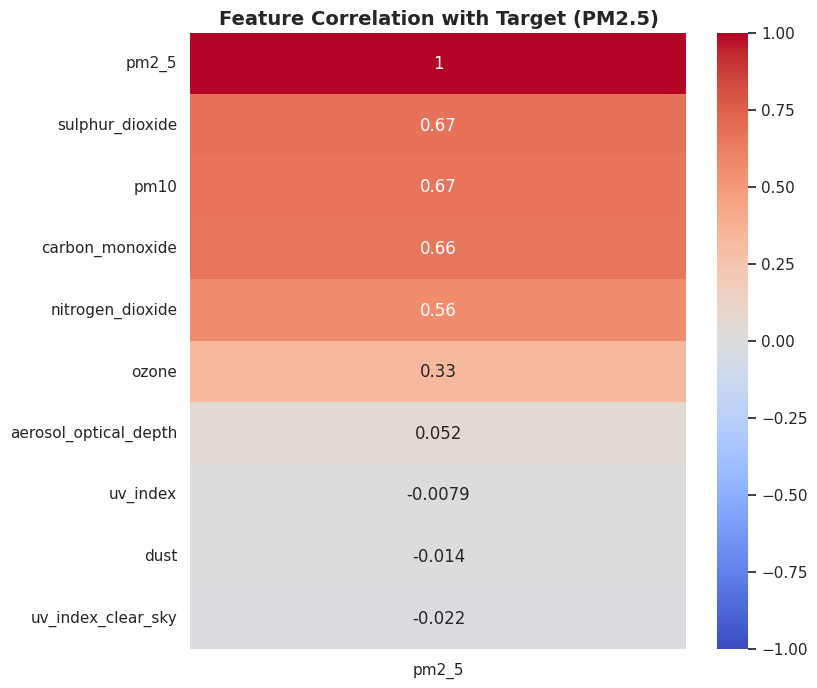

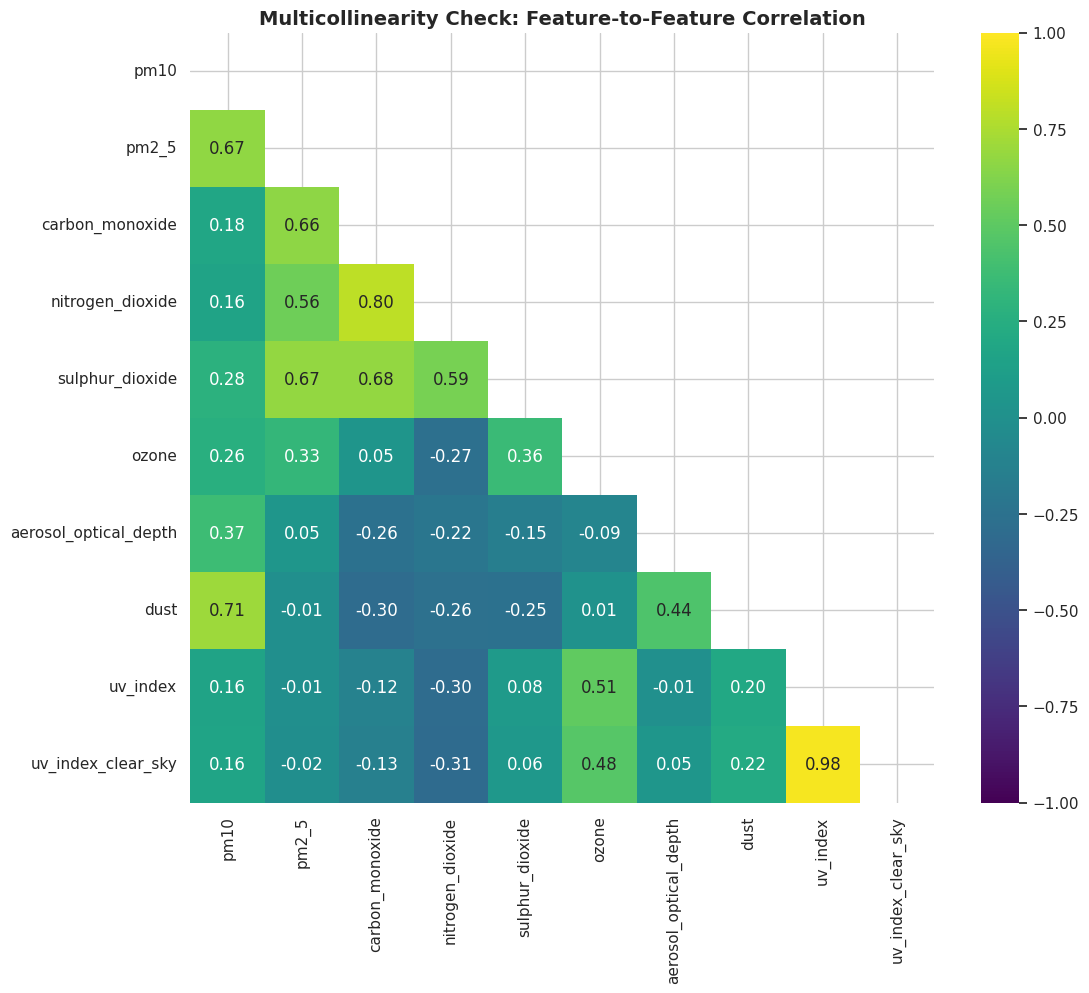


--- MULTICOLLINEARITY ALERTS ---
🚨 High Overlap Detected: 'uv_index_clear_sky' and 'uv_index' (0.98)

Recommendation: Consider dropping one feature from each overlapping pair to simplify the model.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate the correlation matrix (excluding the 'time' column)
corr = df.drop(columns=['time']).corr()

# --- PLOT 1: Target Correlation ---
plt.figure(figsize=(8, 8))
target_corr = corr[['pm2_5']].sort_values(by='pm2_5', ascending=False)
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation with Target (PM2.5)", fontsize=14, fontweight='bold')
plt.show()

# --- PLOT 2: Feature-to-Feature Correlation ---
plt.figure(figsize=(12, 10))
# Create a mask to hide the upper triangle of the heatmap for a cleaner, professional look
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1)
plt.title("Multicollinearity Check: Feature-to-Feature Correlation", fontsize=14, fontweight='bold')
plt.show()

# --- AUTOMATED MULTICOLLINEARITY SCRIPT ---
print("\n--- MULTICOLLINEARITY ALERTS ---")
threshold = 0.85 # Standard threshold for high correlation
flagged = False

# Loop through the matrix to find highly correlated pairs
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            colname_1 = corr.columns[i]
            colname_2 = corr.columns[j]
            correlation_val = corr.iloc[i, j]
            print(f"🚨 High Overlap Detected: '{colname_1}' and '{colname_2}' ({correlation_val:.2f})")
            flagged = True

if not flagged:
    print("✅ No severe multicollinearity detected. All features are unique.")
else:
    print("\nRecommendation: Consider dropping one feature from each overlapping pair to simplify the model.")

### Systematic EDA Step 7: Resolving Multicollinearity
Our automated correlation script flagged a severe multicollinearity alert: a 0.98 overlap between `uv_index` and `uv_index_clear_sky`.

This indicates that both features provide the exact same mathematical signal to the model. Keeping both violates the independent variable assumption of linear regression models. To optimize our feature space and prevent model confusion, we systematically drop `uv_index_clear_sky`.

In [9]:
# 1. Resolve Multicollinearity
print("🚨 Dropping 'uv_index_clear_sky' due to severe multicollinearity (0.98 overlap).")
df = df.drop(columns=['uv_index_clear_sky'])

# 2. FEATURE ENGINEERING: Time Context
df['hour'] = df['time'].dt.hour
df['day'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.dayofweek

# 3. FEATURE ENGINEERING: Momentum (Rate of Change)
# We calculate the hour-over-hour change for all remaining environmental variables
remaining_features = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index']

for col in remaining_features:
    df[f'{col}_change'] = df[col].diff()

# The first row will have NaNs from the diff() function, so we fill them with 0
df = df.fillna(0)

print("\n✅ Feature Engineering Complete!")
print(f"Final Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.")

🚨 Dropping 'uv_index_clear_sky' due to severe multicollinearity (0.98 overlap).

✅ Feature Engineering Complete!
Final Dataset Shape: 33432 rows and 23 columns.


### Systematic EDA Step 8: Evaluating Engineered Features & The Non-Linear Trap
After engineering our temporal (`hour`, `month`) and momentum (`_change`) features, we must evaluate their relationship with the target.

**The Linear Correlation Trap:**
We will calculate the Pearson correlation for our new features, but we will intentionally *not* drop temporal features that score near 0.0. Pearson only detects linear relationships. Time-based human activity (like traffic rush hours) is cyclical and non-linear (e.g., pollution spikes at hour 8 and hour 20, but drops in between). While a linear model like Ridge Regression may struggle with this, our tree-based models (like Random Forest) will easily capture these non-linear temporal splits.

/tmp/ipykernel_10882/1818962457.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=engineered_corr['pm2_5'], y=engineered_corr.index, palette='mako')


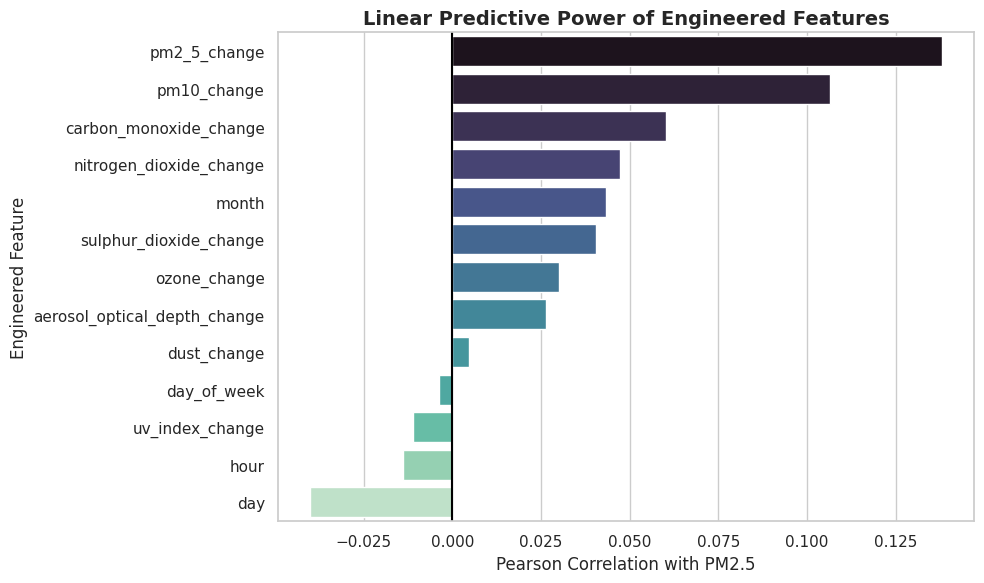

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation of all features with pm2_5
final_corr = df.corr()[['pm2_5']].sort_values(by='pm2_5', ascending=False)

# Filter out the original features so we only look at the ones we just engineered
# (Plus we remove the target 'pm2_5' itself, which is obviously 1.0)
engineered_cols = [c for c in df.columns if '_change' in c or c in ['hour', 'day', 'month', 'day_of_week']]
engineered_corr = final_corr.loc[engineered_cols].sort_values(by='pm2_5', ascending=False)

# Plot the predictive power of our engineered features
plt.figure(figsize=(10, 6))
sns.barplot(x=engineered_corr['pm2_5'], y=engineered_corr.index, palette='mako')

plt.title("Linear Predictive Power of Engineered Features", fontsize=14, fontweight='bold')
plt.xlabel("Pearson Correlation with PM2.5")
plt.ylabel("Engineered Feature")
plt.axvline(x=0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

In [11]:
df.shape

(33432, 23)

In [13]:
import hopsworks

# Connect to Hopsworks
print("Connecting to Hopsworks...")
project = hopsworks.login()
fs = project.get_feature_store()

# THE FIX: We change version=1 to version=2 to create a brand new schema!
aqi_fg = fs.get_or_create_feature_group(
    name="karachi_aqi_features",
    version=2,
    primary_key=["time"],
    description="Ultimate hourly air quality and weather features for Karachi (V2)"
)

print("Uploading ultimate dataset to Hopsworks...")
aqi_fg.insert(df)
print("Upload complete! The Feature Store V2 is updated.")

Connecting to Hopsworks...

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33022
Uploading ultimate dataset to Hopsworks...
Feature Group created successfully, explore it at 
https://eu-west.cloud.hopsworks.ai:443/p/33022/fs/21706/fg/41826


Upload complete! The Feature Store V2 is updated.
